# Exercise 7.2d solution


In [1]:
# --- Setup code from previous sub-exercises ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def V_target(t):
    return -80 + 40 * (t > 2) * (t < 6)


def rhs(t, V, Cm, Rs):
    dV_dt = (V_target(t) - V) / (Cm * Rs)
    return dV_dt


# Define time array
time = (0, 10)

# Define parameters
Cm = 0.05  # nF
Rs = 10  # MOhm
params = (Cm, Rs)

# Define initial condition
y0 = (-80,)

# Call solve_ivp
solution = solve_ivp(rhs, time, y0, args=params, max_step=0.1)

t = solution.t
(V,) = solution.y

# ----------------------------------------------

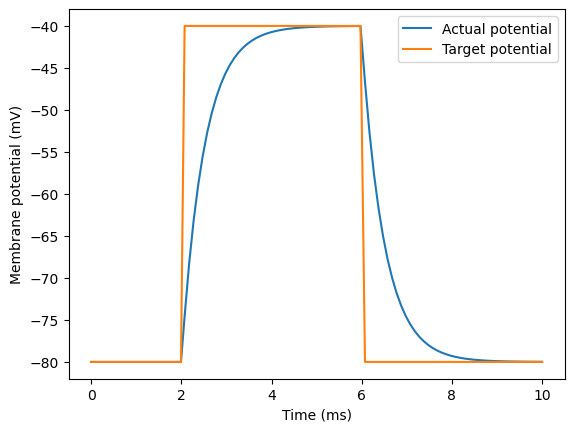

In [2]:
plt.plot(t, V, label="Actual potential")
plt.plot(t, V_target(t), label="Target potential")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.legend()
plt.show()

We can clearly see that the computed membrane potential $V$ does indeed follow the prescribed target potential, but with a substantial delay.

While the target potential undergoes a perfect step change (an instantaneous jump), the actual membrane potential requires physical time to "catch up" to this new state. The resulting curved shape of the actual membrane potential is what we call an _exponential relaxation_ toward the target value.
